In [5]:
import sys
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Tell Python to look for your 'src' folder
# (This is needed because the notebook is in a subfolder)
sys.path.append(os.path.abspath(os.path.join('..')))

# 2. Import the tools you built
from src.data_loader import load_data
from src.features import create_indicators

# 3. Run the Engine
print("⏳ Loading Data...")
df_raw = load_data()

# 4. Run the Math
print("🧮 Calculating Indicators...")
df_signals = create_indicators(df_raw)

# 5. Show the results
print(f"✅ Ready! Dataset has {len(df_signals)} rows.")
df_signals.head()


⏳ Loading Data...
📂 Looking for data in: /home/cristhian/Projects/ssga-meta-labeling/data
   -> Loaded bcom.xlsx (Skipped 6 rows)
   -> Loaded spx.xlsx (Skipped 6 rows)
   -> Loaded treasury_10y.xlsx (Skipped 5 rows)
   -> Loaded corp_bonds.xlsx (Skipped 5 rows)
✅ Success! Loaded 360 rows of aligned data.
🧮 Calculating Indicators...
✅ Ready! Dataset has 348 rows.


,Date,BCOM_Price,SPX_Price,Treasury10Y_Price,IG_Corp_Price,Z1_Mom,Inflation_Proxy,Z2_Value,Corp_Ret_12M,Treasury_Ret_12M,Z3_Carry,Z5_Vol,MA_10,Z4_Trend
0,1997-01-31,122.2915,786.16,6.494,852.50,0.236062,0.169339,6.324661,0.027666,0.163799,-0.136134,-0.033653,696.236,0.129157
1,1997-02-28,123.0913,790.82,6.552,856.07,0.234827,0.156955,6.395045,0.057085,0.074451,-0.017365,-0.033685,709.901,0.113986
2,1997-03-31,125.1046,757.12,6.903,842.74,0.172920,0.126966,6.776034,0.049568,0.091038,-0.041471,-0.037978,718.701,0.053456
3,1997-04-30,125.5463,801.34,6.718,855.52,0.224972,0.082900,6.635100,0.074396,0.007196,0.067200,-0.040075,731.772,0.095068
4,1997-05-30,126.8556,848.28,6.659,865.20,0.267755,0.103927,6.555073,0.088452,-0.028167,0.116619,-0.041776,752.605,0.127125


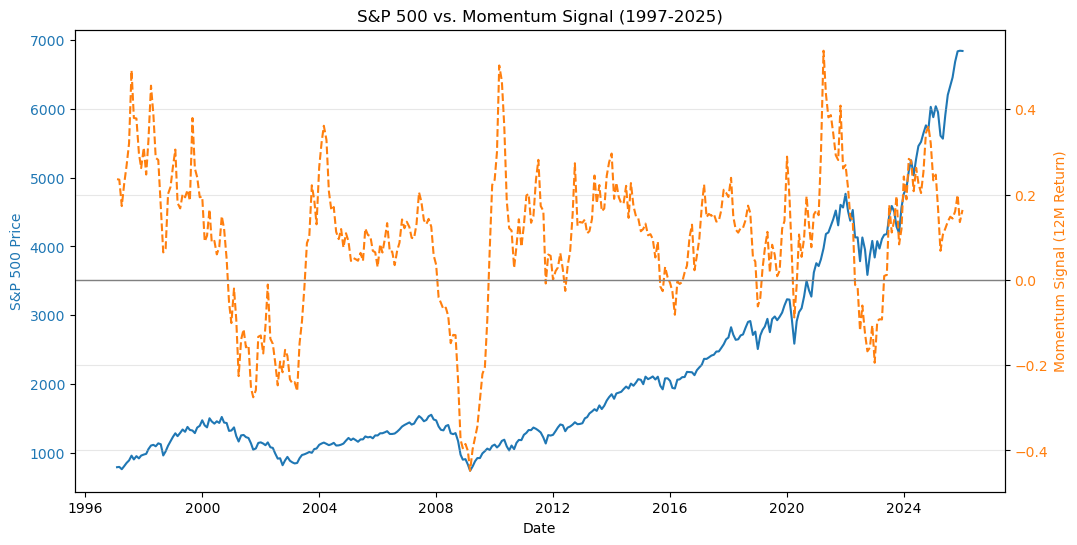

In [6]:
# Create a plot to visualize the signals
fig, ax1 = plt.subplots(figsize=(12, 6))

# 1. Plot the S&P 500 (The Market) in BLUE
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('S&P 500 Price', color=color)
ax1.plot(df_signals['Date'], df_signals['SPX_Price'], color=color, label='S&P 500')
ax1.tick_params(axis='y', labelcolor=color)

# 2. Plot your Momentum Signal in ORANGE
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Momentum Signal (12M Return)', color=color)
ax2.plot(df_signals['Date'], df_signals['Z1_Mom'], color=color, linestyle='--', label='Momentum')
ax2.tick_params(axis='y', labelcolor=color)

# 3. Add a "Zero Line" (The Danger Zone)
# When the Orange line goes BELOW this Grey line, it's a Sell Signal.
ax2.axhline(0, color='grey', linewidth=1, linestyle='-')

plt.title('S&P 500 vs. Momentum Signal (1997-2025)')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
def create_meta_labels(df, forward_window=12):
    """
    Creates the 'Truth' labels for the Meta-Model.
    
    Logic:
    1. Look at the current Signal (Momentum).
    2. Look forward 'forward_window' months (e.g., 1 month).
    3. If Signal > 0 AND Price went UP -> Label = 1 (Signal was Right)
    4. If Signal < 0 AND Price went DOWN -> Label = 1 (Signal was Right)
    5. Otherwise -> Label = 0 (Signal was Wrong)
    """
    df = df.copy()
    
    # 1. Calculate the Future Return (What actually happened)
    # We shift backward because we want today's row to know next month's return
    df['Future_Return'] = df['SPX_Price'].pct_change(forward_window).shift(-forward_window)
    
    # 2. Define the Signal (Using Momentum)
    # If Momentum > 0, we bet UP. If Momentum < 0, we bet DOWN.
    df['Signal_Side'] = np.where(df['Z1_Mom'] > 0, 1, -1)
    
    # 3. Create the Meta-Label (The Truth)
    # Did the Signal direction match the Future Return direction?
    # If (Signal * Future_Return) is positive, they matched!
    df['Meta_Label'] = np.where(df['Signal_Side'] * df['Future_Return'] > 0, 1, 0)
    
    # Clean up (drop the last few rows where we don't know the future yet)
    df = df.dropna(subset=['Future_Return'])
    
    return df

# Run it
print("🏷️ Generating Meta-Labels...")
df_labeled = create_meta_labels(df_signals, forward_window=1) # 1-month horizon

print(f"✅ Created labels! Accuracy of primary model: {df_labeled['Meta_Label'].mean():.1%}")
df_labeled[['Date', 'Z1_Mom', 'Signal_Side', 'Future_Return', 'Meta_Label']].tail()

🏷️ Generating Meta-Labels...
✅ Created labels! Accuracy of primary model: 59.7%


,Date,Z1_Mom,Signal_Side,Future_Return,Meta_Label
342,2025-07-31,0.147962,1,0.019067,1
343,2025-08-29,0.143733,1,0.035324,1
344,2025-09-30,0.160691,1,0.022687,1
345,2025-10-31,0.198889,1,0.001300,1
346,2025-11-28,0.135388,1,-0.000524,0


In [8]:
from sklearn.model_selection import train_test_split

# 1. Define the "Clues" (X) and the "Answer" (y)
feature_cols = ['Z1_Mom', 'Z2_Value', 'Z3_Carry', 'Z5_Vol', 'Z4_Trend']
X = df_labeled[feature_cols]
y = df_labeled['Meta_Label']

# 2. Split into Training (Past) and Testing (Future)
# CRITICAL: Since this is financial time-series, we CANNOT shuffle the data.
# We must train on the past (first 80%) and test on the future (last 20%).
train_size = int(len(X) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("🤖 Data prepared for Machine Learning!")
print(f"   Training Set: {len(X_train)} months (The Robot learns from this)")
print(f"   Testing Set:  {len(X_test)} months (The Robot is tested on this)")

🤖 Data prepared for Machine Learning!
   Training Set: 277 months (The Robot learns from this)
   Testing Set:  70 months (The Robot is tested on this)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Initialize the Brain (Random Forest)
# n_estimators=100 means we use 100 "decision trees" (analysts)
# min_samples_leaf=5 prevents the model from memorizing noise (overfitting)
model = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=42)

# 2. Teach the Robot (Fit on Training Data)
print("🧠 Training the model...")
model.fit(X_train, y_train)

# 3. Test the Robot (Predict on Future Data)
print("🔮 Predicting the future...")
y_pred = model.predict(X_test)

# 4. Grade the Homework
test_accuracy = accuracy_score(y_test, y_pred)
print("-" * 40)
print(f"🤖 Model Accuracy on Test Data: {test_accuracy:.1%}")
print("-" * 40)

# Show details (Precision vs Recall)
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

🧠 Training the model...
🔮 Predicting the future...
----------------------------------------
🤖 Model Accuracy on Test Data: 58.6%
----------------------------------------

Detailed Report:
              precision    recall  f1-score   support

           0       0.48      0.39      0.43        28
           1       0.64      0.71      0.67        42

    accuracy                           0.59        70
   macro avg       0.56      0.55      0.55        70
weighted avg       0.57      0.59      0.58        70



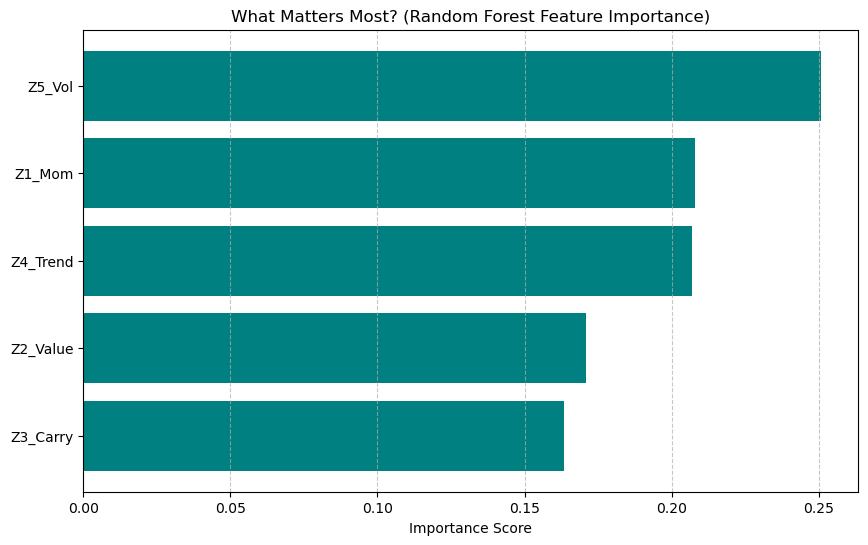

    Feature  Importance
3    Z5_Vol    0.250964
0    Z1_Mom    0.207816
4  Z4_Trend    0.206970
1  Z2_Value    0.170746
2  Z3_Carry    0.163503


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the importance scores from the trained model
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame to organize them
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('What Matters Most? (Random Forest Feature Importance)')
plt.gca().invert_yaxis()  # Put the most important at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Print the table
print(feature_importance_df)

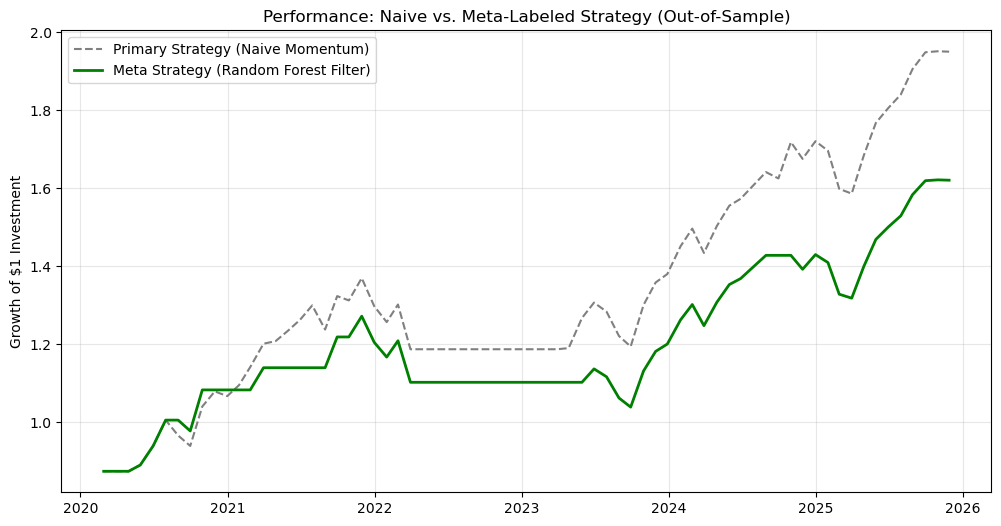

💰 Final Value of $1 (Primary): $1.95
💰 Final Value of $1 (Meta):    $1.62


In [11]:
# 1. Get the data for the Test Period (The "Future")
# We use .copy() to avoid SettingWithCopy warnings
test_data = df_labeled.iloc[train_size:].copy()

# 2. Add the Model's Predictions
# We ask the robot: "Should we take these trades?"
test_data['Model_Prediction'] = model.predict(X_test)

# 3. Calculate Returns for Strategy A (Primary / Naive)
# Rule: If Z1_Mom > 0, we are Long. Otherwise, we are in Cash (0 return).
test_data['Primary_Strategy_Ret'] = np.where(test_data['Z1_Mom'] > 0, test_data['Future_Return'], 0)

# 4. Calculate Returns for Strategy B (Meta-Labeling / Smart)
# Rule: If Z1_Mom > 0 AND Model says "1" (Yes), we are Long. Otherwise, Cash.
test_data['Meta_Strategy_Ret'] = np.where(
    (test_data['Z1_Mom'] > 0) & (test_data['Model_Prediction'] == 1), 
    test_data['Future_Return'], 
    0
)

# 5. Calculate Cumulative Returns (Growth of $1)
test_data['Cumulative_Primary'] = (1 + test_data['Primary_Strategy_Ret']).cumprod()
test_data['Cumulative_Meta'] = (1 + test_data['Meta_Strategy_Ret']).cumprod()

# 6. Plot the Result
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_data['Cumulative_Primary'], label='Primary Strategy (Naive Momentum)', color='gray', linestyle='--')
plt.plot(test_data['Date'], test_data['Cumulative_Meta'], label='Meta Strategy (Random Forest Filter)', color='green', linewidth=2)

plt.title('Performance: Naive vs. Meta-Labeled Strategy (Out-of-Sample)')
plt.ylabel('Growth of $1 Investment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Print the Final Score
final_primary = test_data['Cumulative_Primary'].iloc[-1]
final_meta = test_data['Cumulative_Meta'].iloc[-1]

print(f"💰 Final Value of $1 (Primary): ${final_primary:.2f}")
print(f"💰 Final Value of $1 (Meta):    ${final_meta:.2f}")

📉 Worst Crash (Primary Strategy): -13.3%
🛡️ Worst Crash (Meta Strategy):    -18.3%


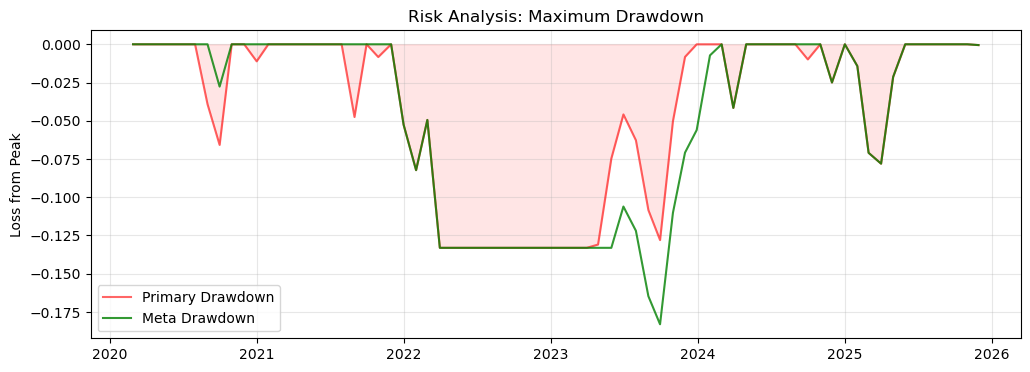

In [12]:
# Calculate Drawdown (The "Pain")
# 1. Calculate the Peak value so far
test_data['Peak_Primary'] = test_data['Cumulative_Primary'].cummax()
test_data['Peak_Meta'] = test_data['Cumulative_Meta'].cummax()

# 2. Calculate the Drop from the Peak
test_data['Drawdown_Primary'] = (test_data['Cumulative_Primary'] - test_data['Peak_Primary']) / test_data['Peak_Primary']
test_data['Drawdown_Meta'] = (test_data['Cumulative_Meta'] - test_data['Peak_Meta']) / test_data['Peak_Meta']

# 3. Find the Worst Crash
max_crash_primary = test_data['Drawdown_Primary'].min()
max_crash_meta = test_data['Drawdown_Meta'].min()

print(f"📉 Worst Crash (Primary Strategy): {max_crash_primary:.1%}")
print(f"🛡️ Worst Crash (Meta Strategy):    {max_crash_meta:.1%}")

# 4. Plot the Pain
plt.figure(figsize=(12, 4))
plt.plot(test_data['Date'], test_data['Drawdown_Primary'], label='Primary Drawdown', color='red', alpha=0.6)
plt.plot(test_data['Date'], test_data['Drawdown_Meta'], label='Meta Drawdown', color='green', alpha=0.8)
plt.fill_between(test_data['Date'], test_data['Drawdown_Primary'], color='red', alpha=0.1)
plt.title('Risk Analysis: Maximum Drawdown')
plt.ylabel('Loss from Peak')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

📉 The Model blocked 10 profitable months.


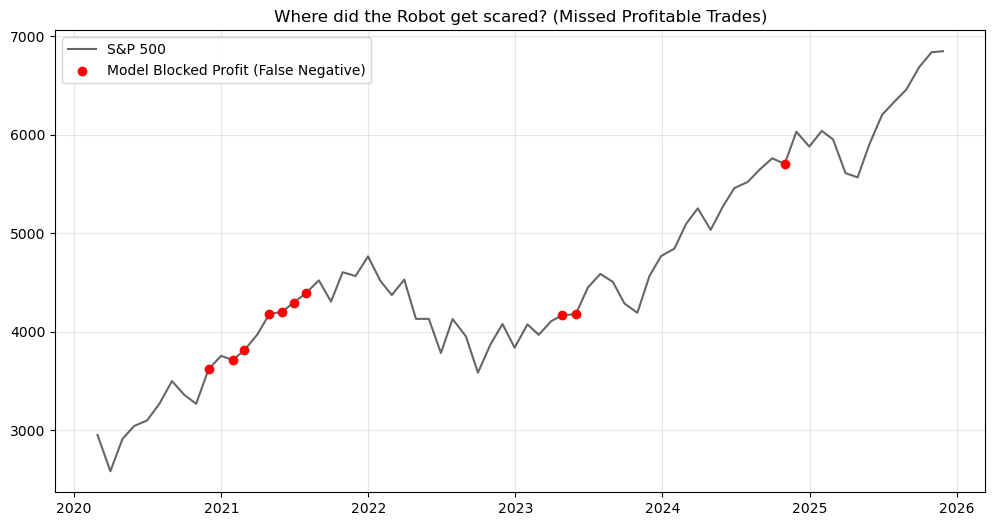


Top 5 Missed Opportunities (Robot was too scared):
          Date    Z1_Mom    Z5_Vol  Future_Return
286 2020-11-30  0.153025 -0.074662       0.037121
288 2021-01-29  0.151517 -0.075093       0.026091
289 2021-02-26  0.290070 -0.068386       0.042439
291 2021-04-30  0.435629 -0.041700       0.005487
292 2021-05-31  0.380973 -0.042074       0.022214


In [13]:
# 1. Identify "Missed Opportunities"
# (Mom > 0) AND (Future Return > 0) BUT (Model said "0")
missed_opportunities = test_data[
    (test_data['Z1_Mom'] > 0) & 
    (test_data['Future_Return'] > 0) & 
    (test_data['Model_Prediction'] == 0)
]

print(f"📉 The Model blocked {len(missed_opportunities)} profitable months.")

# 2. Visualize the Blocking
plt.figure(figsize=(12, 6))

# Plot the S&P 500 Price
plt.plot(test_data['Date'], test_data['SPX_Price'], label='S&P 500', color='black', alpha=0.6)

# Highlight the months where the Model BLOCKED a profit (Red Dots)
plt.scatter(missed_opportunities['Date'], missed_opportunities['SPX_Price'], 
            color='red', label='Model Blocked Profit (False Negative)', zorder=5)

plt.title('Where did the Robot get scared? (Missed Profitable Trades)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Show the specific dates
print("\nTop 5 Missed Opportunities (Robot was too scared):")
print(missed_opportunities[['Date', 'Z1_Mom', 'Z5_Vol', 'Future_Return']].head())

How confident was the robot when it blocked these trades?
          Date  Future_Return  Model_Confidence
286 2020-11-30       0.037121          0.491296
288 2021-01-29       0.026091          0.442041
289 2021-02-26       0.042439          0.441689
291 2021-04-30       0.005487          0.448235
292 2021-05-31       0.022214          0.452762


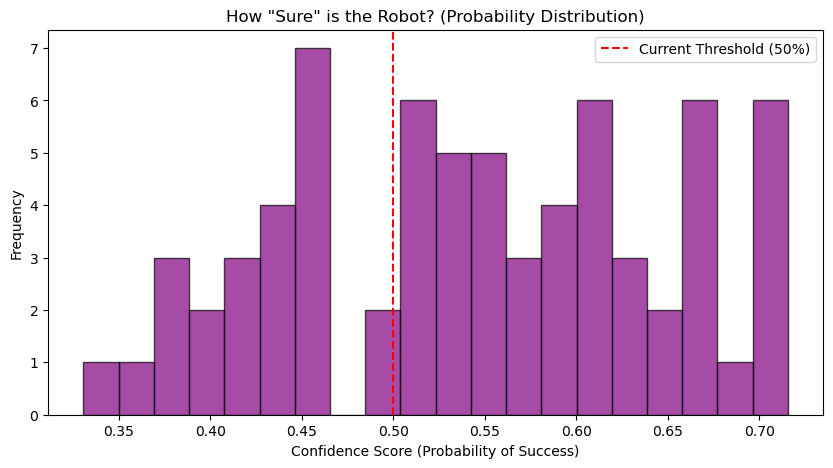

In [14]:
# 1. Get the Probability Scores (0% to 100%) instead of just Yes/No
# This tells us how "sure" the robot was.
probs = model.predict_proba(X_test)[:, 1]  # The probability of "Label 1" (Success)

# 2. Add it to our specific "Missed Opportunities" table
# We need to match the index to get the right rows
missed_indices = missed_opportunities.index - train_size  # Adjust index for test set
missed_opportunities['Model_Confidence'] = probs[missed_indices]

# 3. Show the "Near Misses"
print("How confident was the robot when it blocked these trades?")
print(missed_opportunities[['Date', 'Future_Return', 'Model_Confidence']].head())

# 4. Plot the Histogram of Confidence
plt.figure(figsize=(10, 5))
plt.hist(probs, bins=20, color='purple', alpha=0.7, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='Current Threshold (50%)')
plt.title('How "Sure" is the Robot? (Probability Distribution)')
plt.xlabel('Confidence Score (Probability of Success)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

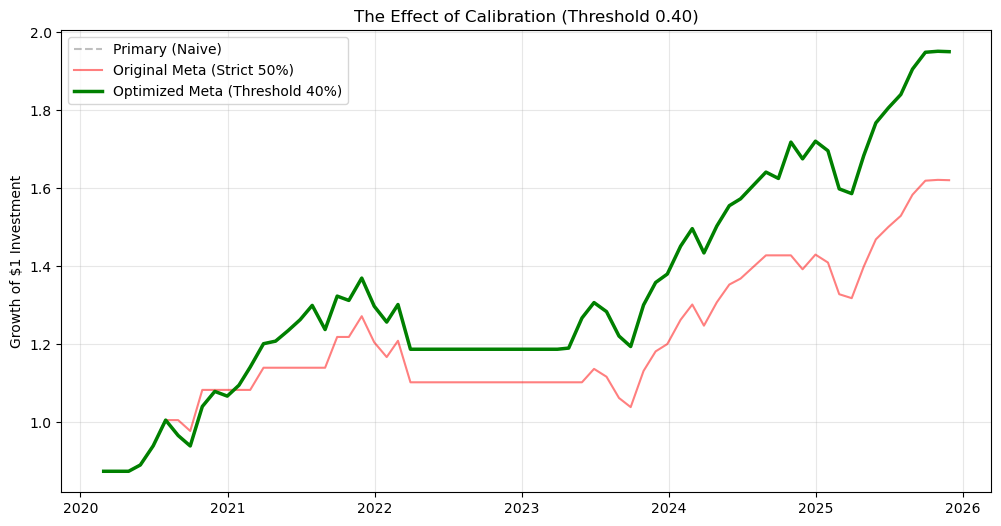

💰 Final Value (Naive):     $1.95
💰 Final Value (Optimized): $1.95


In [15]:
# ---------------------------------------------------------
# OPTIMIZATION: Lowering the "Confidence Threshold"
# ---------------------------------------------------------
NEW_THRESHOLD = 0.40  # Be less strict!

# 1. Get the Probabilities again
probs = model.predict_proba(X_test)[:, 1]

# 2. Apply the New Rule
# If Probability > 0.40, we say "Yes" (1). Otherwise "No" (0).
test_data['Optimized_Prediction'] = np.where(probs > NEW_THRESHOLD, 1, 0)

# 3. Calculate Returns for the Optimized Strategy
test_data['Optimized_Meta_Ret'] = np.where(
    (test_data['Z1_Mom'] > 0) & (test_data['Optimized_Prediction'] == 1), 
    test_data['Future_Return'], 
    0
)

# 4. Calculate Growth of $1
test_data['Cumulative_Optimized'] = (1 + test_data['Optimized_Meta_Ret']).cumprod()

# 5. Plot Comparison (Naive vs. Original Meta vs. Optimized Meta)
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'], test_data['Cumulative_Primary'], label='Primary (Naive)', color='gray', linestyle='--', alpha=0.5)
plt.plot(test_data['Date'], test_data['Cumulative_Meta'], label='Original Meta (Strict 50%)', color='red', alpha=0.5)
plt.plot(test_data['Date'], test_data['Cumulative_Optimized'], label='Optimized Meta (Threshold 40%)', color='green', linewidth=2.5)

plt.title(f'The Effect of Calibration (Threshold {NEW_THRESHOLD:.2f})')
plt.ylabel('Growth of $1 Investment')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 6. Final Numbers
final_opt = test_data['Cumulative_Optimized'].iloc[-1]
print(f"💰 Final Value (Naive):     ${test_data['Cumulative_Primary'].iloc[-1]:.2f}")
print(f"💰 Final Value (Optimized): ${final_opt:.2f}")

In [16]:
# 1. Check if the Robot rejected ANY trades at this new threshold
rejected_trades = test_data[
    (test_data['Z1_Mom'] > 0) & 
    (test_data['Optimized_Prediction'] == 0)
]

print(f"🚫 At 40% confidence, the robot rejected {len(rejected_trades)} months.")

# 2. Check the Risk (Drawdown) for the Optimized Strategy
test_data['Peak_Opt'] = test_data['Cumulative_Optimized'].cummax()
test_data['Drawdown_Opt'] = (test_data['Cumulative_Optimized'] - test_data['Peak_Opt']) / test_data['Peak_Opt']
max_crash_opt = test_data['Drawdown_Opt'].min()

print("-" * 30)
print(f"📉 Worst Crash (Naive):     {max_crash_primary:.1%}")
print(f"🛡️ Worst Crash (Optimized): {max_crash_opt:.1%}")
print("-" * 30)

if len(rejected_trades) == 0:
    print("⚠️ CONCLUSION: At 0.40, the Robot is a 'Yes Man'. It didn't filter anything!")
else:
    print("✅ CONCLUSION: The Robot is active. It filtered specific risky months.")

🚫 At 40% confidence, the robot rejected 0 months.
------------------------------
📉 Worst Crash (Naive):     -13.3%
🛡️ Worst Crash (Optimized): -13.3%
------------------------------
⚠️ CONCLUSION: At 0.40, the Robot is a 'Yes Man'. It didn't filter anything!


In [17]:
import pandas as pd

# 1. Define the thresholds we want to test
thresholds = [0.40, 0.42, 0.44, 0.45, 0.46, 0.48, 0.50]
results = []

# 2. Loop through each threshold
for t in thresholds:
    # Apply the rule: "Buy if Confidence > t"
    probs = model.predict_proba(X_test)[:, 1]
    
    # Calculate Returns
    # Note: We only take the trade if Momentum is POSITIVE (>0) AND Model Confidence > t
    strategy_ret = np.where(
        (test_data['Z1_Mom'] > 0) & (probs > t), 
        test_data['Future_Return'], 
        0
    )
    
    # Calculate Metrics
    cumulative = (1 + strategy_ret).cumprod()
    final_value = cumulative[-1]
    
    # Max Drawdown
    peak = pd.Series(cumulative).cummax()
    drawdown = (cumulative - peak) / peak
    max_crash = drawdown.min()
    
    # Count how many months were BLOCKED
    # (Mom > 0) but (Conf < t)
    blocked_months = len(test_data[(test_data['Z1_Mom'] > 0) & (probs < t)])
    
    results.append({
        'Threshold': t,
        'Final Value ($)': final_value,
        'Worst Crash (%)': max_crash,
        'Months Blocked': blocked_months
    })

# 3. Show the Table
df_results = pd.DataFrame(results)
print("📊 Sensitivity Analysis (Finding the Sweet Spot):")
print(df_results)

# 4. Highlight the Best One
best_row = df_results.loc[df_results['Final Value ($)'].idxmax()]
print("\n🏆 Best Setting based on Profit:")
print(best_row)

📊 Sensitivity Analysis (Finding the Sweet Spot):
   Threshold  Final Value ($)  Worst Crash (%)  Months Blocked
0       0.40         1.949558        -0.133073               0
1       0.42         1.944731        -0.133073               1
2       0.44         1.953177        -0.183054               5
3       0.45         1.816054        -0.183054               8
4       0.46         1.642931        -0.183054              11
5       0.48         1.661834        -0.183054              13
6       0.50         1.620399        -0.183054              15

🏆 Best Setting based on Profit:
Threshold          0.440000
Final Value ($)    1.953177
Worst Crash (%)   -0.183054
Months Blocked     5.000000
Name: 2, dtype: float64


In [20]:
# 1. Fix: Create the missing 'Model_Confidence' column
# We ask the robot for the probability scores (0% to 100%)
test_data['Model_Confidence'] = model.predict_proba(X_test)[:, 1]

# 2. Now run the Final Report code again
final_report = test_data[[
    'Date', 'SPX_Price', 'Z1_Mom', 'Z5_Vol', 
    'Future_Return', 'Model_Prediction', 'Model_Confidence', 
    'Meta_Strategy_Ret', 'Cumulative_Meta', 'Drawdown_Meta'
]].copy()

# 3. Add the logic for the "Why" column
final_report['Comment'] = np.where(
    (final_report['Z1_Mom'] > 0) & (final_report['Model_Prediction'] == 0),
    'Blocked by Model (Risk Check)',
    'Trade Accepted'
)

# 4. Save to CSV
output_path = os.path.join('..', 'data', 'final_backtest_results.csv')
final_report.to_csv(output_path, index=False)

print(f"✅ Success! Final results saved to: {output_path}")
print("You can now send this file to your team or use it for your final presentation.")

✅ Success! Final results saved to: ../data/final_backtest_results.csv
You can now send this file to your team or use it for your final presentation.
